# Time Series Analysis

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import Checkbox, Output, Layout, GridBox

import sys
sys.path.append('../src')
from helpers import column_utils, csv_utils

In [20]:
df = csv_utils.csv_read('../data/cleaned/merged_ras_base_right_join_copy.csv', ',')

***

## Filtering 

We will apply some filters to get the data we want to plot. 

- First we will filter out any of the Special Team positions, these include Long Snapper (LS) and Place Kicker (PK)
    - These positions tend to have very low RAS scores, and they are on the field a shorter amount of time compared to other positions
- Next, we will filter out any Undrafted players, since this analysis is only looking at NFL Draft activity
- Let's also filter out any players without a RAS score. We do not want the median RAS calculation to be skewed by players with missing scores.

In [21]:
df_filtered = df[~df['POS'].isin(['ST', 'LS', 'PK'])]
df_filtered = df_filtered[df_filtered['Round'].notna()]
df_filtered = df_filtered[df_filtered['RAS'].notna()]

## Combining Positions

There are many positions represented within our dataset. In order to cut down on the number of lines we will plot, we will group specific position under its general position category. As an example, a center (OC) will have its positioned changed to offensive lineman (OL)

- Defensive Lineman (DL)
    - Includes DT and DE  
- Offnsive Lineman (OL)
    - OC, OG, OT
- Defensive Back (DB)
    - S, SS, FS, CB
- Running Back (RB)
    - FB

In [22]:
df_filtered['POS'] = column_utils.column_replace_value(df_filtered['POS'], column_utils.DEFENSIVE_BACKS, 'DB')
df_filtered['POS'] = column_utils.column_replace_value(df_filtered['POS'], column_utils.DEFENSIVE_LINEMAN, 'DL')
df_filtered['POS'] = column_utils.column_replace_value(df_filtered['POS'], column_utils.OFFENSIVE_LINEMAN, 'OL')
df_filtered['POS'] = column_utils.column_replace_value(df_filtered['POS'], column_utils.RUNNING_BACKS, 'RB')

***

## Creating The DataFrames using `groupby`

In [23]:
df_ras_position = df_filtered.groupby(['Year', 'POS'])['RAS'].median().reset_index()
df_ras_round = df_filtered.groupby(['Year', 'Round'])['RAS'].median().reset_index()

For the x axis tick marks, lets use every year value from our dataset

In [24]:
years = sorted(df_filtered['Year'].unique())

In [25]:
def plot_lines(df, filter_col, selection):
    if len(selection) == 0:
        display("Select at least one value")
        return
    
    col_dtype = df[filter_col].dtype

    try:
        selection = [col_dtype.type(v) for v in selection]
    except:
        selection = [int(v) if v.isdigit() else v for v in selection]
    df_ras_filter_col = df[df[filter_col].isin(selection)].groupby(['Year', filter_col])['RAS'].median().reset_index()
    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(data=df_ras_filter_col, x='Year', y='RAS', hue=filter_col)
    ax.legend(title=f"{'Position' if filter_col == 'POS' else 'Draft Round'} (Selected)", loc='upper left')
    plt.title(f"Median RAS of Drafted NFL Player by {'Position' if filter_col == 'POS' else 'Draft Round'} each Year")
    plt.xlabel("Year")
    plt.ylabel("Median RAS")
    plt.xticks(rotation=45, ticks=years)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [26]:
def interactive_line_plot_checkboxes(df, filter_col):
    values = sorted(df[filter_col].dropna().unique())
    checkboxes = [Checkbox(
            value=False,
            description=str(v)) for v in values]
    ui = GridBox(
    checkboxes,
    layout=Layout(
        grid_template_columns="repeat(4, 90px)",
        grid_gap="2px 5px",
        margin="0"
    )
    )
    out = Output()
    def update_plot(change):
        selected = [cb.description for cb in checkboxes if cb.value]
        out.clear_output(wait=True)
        with out:
            plot_lines(df, filter_col, selected)

    for cb in checkboxes:
        cb.unobserve_all()
        cb.observe(update_plot, "value")

    display(ui, out)

In [ ]:

interactive_line_plot_checkboxes(df_ras_position, filter_col="POS")


GridBox(children=(Checkbox(value=False, description='DB'), Checkbox(value=False, description='DL'), Checkbox(v…

Output()

<Axes: xlabel='Year', ylabel='RAS'>

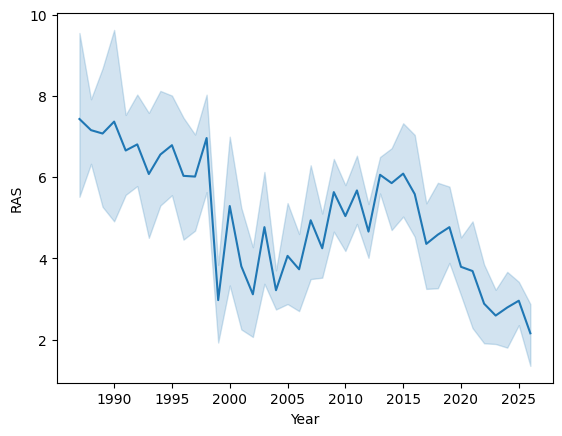

In [28]:
df_ras_position_variance = df_filtered.groupby(['POS', 'Year'])['RAS'].var().reset_index()
df_ras_round_variance = df_filtered.groupby(['Round', 'Year'])['RAS'].var().reset_index()


sns.lineplot(data=df_ras_round_variance, x='Year', y='RAS')


<Axes: xlabel='Year', ylabel='RAS'>

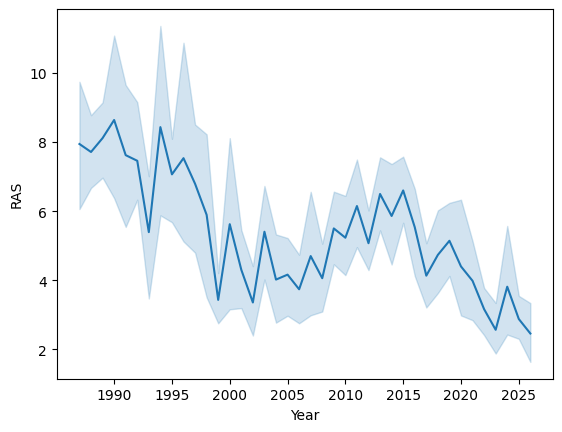

In [29]:
sns.lineplot(data=df_ras_position_variance, x='Year', y='RAS')

In [30]:
interactive_line_plot_checkboxes(df_ras_round, filter_col="Round")

GridBox(children=(Checkbox(value=False, description='1'), Checkbox(value=False, description='2'), Checkbox(val…

Output()